# Perfil econômico — PARTICIPANTES 2025

Qual é o contexto econômico dos inscritos que buscaram essa oportunidade? Este capítulo usa exclusivamente os registros divulgados de PARTICIPANTES, sem vínculo individual com RESULTADOS e sem generalização para a população brasileira.

**Regras:** dicionário 2025, aba PARTICIPANTES_2025, linhas 184–202. Q006 pergunta “Você possui renda?” (A Não, B Sim): não informa valor de renda individual ou situação de emprego. Q007 pergunta renda mensal familiar, incluindo a do inscrito e a das pessoas que moram com ele; categorias A–Q nas faixas nominais de 2025. Não é renda per capita; não calcular média de renda por pontos médios das faixas.

Leitura Latin-1 com `;`, parser estrito, quatro colunas temporárias (chave, ano, Q006 e Q007), sem nova trusted. Espaços externos removidos, vazios tratados como sem resposta. Categorias inesperadas interrompem a publicação. Categorias sem ocorrência e sem resposta permanecem no CSV. Percentual principal: quantidade / total de registros; percentual entre respostas válidas tem denominador separado. Não usar total oficial de inscrições confirmadas no denominador.

Sem testes ou reports novos. Este notebook processa e confere as contagens operacionalmente; a apresentação lê apenas o CSV. Módulos em `src/perfil_economico*.py`; DuckDB 256 MB/uma thread, Pandas só com agregados.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
raiz=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'src/perfil_economico.py').is_file())
if str(raiz) not in sys.path:
    sys.path.insert(0,str(raiz))
from src.perfil_economico_execucao import executar_perfil_economico
from src.perfil_economico_graficos import gerar_graficos_perfil_economico
economico=executar_perfil_economico(raiz)


## Cobertura e contagens

O denominador é toda a base de PARTICIPANTES. A categoria “Sem resposta” fica separada de “Nenhuma renda”. Quantidade e percentuais completos ficam no CSV `analitica/perfil_economico_2025.csv`; SHA-256 da fonte é registrado ali, sem relatório adicional.


In [2]:
tabela_economica=pd.DataFrame(economico)
for pergunta in ['Q007','Q006']:
    recorte=tabela_economica[tabela_economica.pergunta==pergunta]
    assert recorte.quantidade.sum()==recorte.total_base.iloc[0]
    assert recorte.respostas_validas.iloc[0]+recorte.sem_resposta.iloc[0]==recorte.total_base.iloc[0]
    print(pergunta, 'Base:',recorte.total_base.iloc[0], 'Respostas válidas:',recorte.respostas_validas.iloc[0], 'Sem resposta:',recorte.sem_resposta.iloc[0])
    display(recorte[['codigo','categoria','quantidade','percentual_base','percentual_respostas']].round(2))


Q007 Base: 4810772 Respostas válidas: 4810772 Sem resposta: 0


,codigo,categoria,quantidade,percentual_base,percentual_respostas
3,A,Nenhuma renda,479899,9.98,9.98
4,B,"Até R$ 1.518,00",1644626,34.19,34.19
5,C,"De R$ 1.518,01 até R$ 2.277,00",866020,18.00,18.00
6,D,"De R$ 2.277,01 até R$ 3.036,00",434003,9.02,9.02
7,E,"De R$ 3.036,01 até R$ 3.795,00",202017,4.20,4.20
8,F,"De R$ 3.795,01 até R$ 4.554,00",233062,4.84,4.84
9,G,"De R$ 4.554,01 até R$ 6.072,00",271843,5.65,5.65
10,H,"De R$ 6.072,01 até R$ 7.590,00",137918,2.87,2.87
11,I,"De R$ 7.590,01 até R$ 9.108,00",106469,2.21,2.21
12,J,"De R$ 9.108,01 até R$ 10.626,00",85387,1.77,1.77


Q006 Base: 4810772 Respostas válidas: 4810772 Sem resposta: 0


,codigo,categoria,quantidade,percentual_base,percentual_respostas
0,A,Não,3454810,71.81,71.81
1,B,Sim,1355962,28.19,28.19
2,,Sem resposta,0,0.00,NaN


## Renda familiar e renda própria respondem a perguntas diferentes

Categorias familiares na ordem do dicionário, sem ordenar por frequência. A declaração sobre renda própria não informa quanto a pessoa recebe. Cada distribuição é marginal; não se pode combinar percentuais para deduzir a renda familiar de quem respondeu Não em Q006.


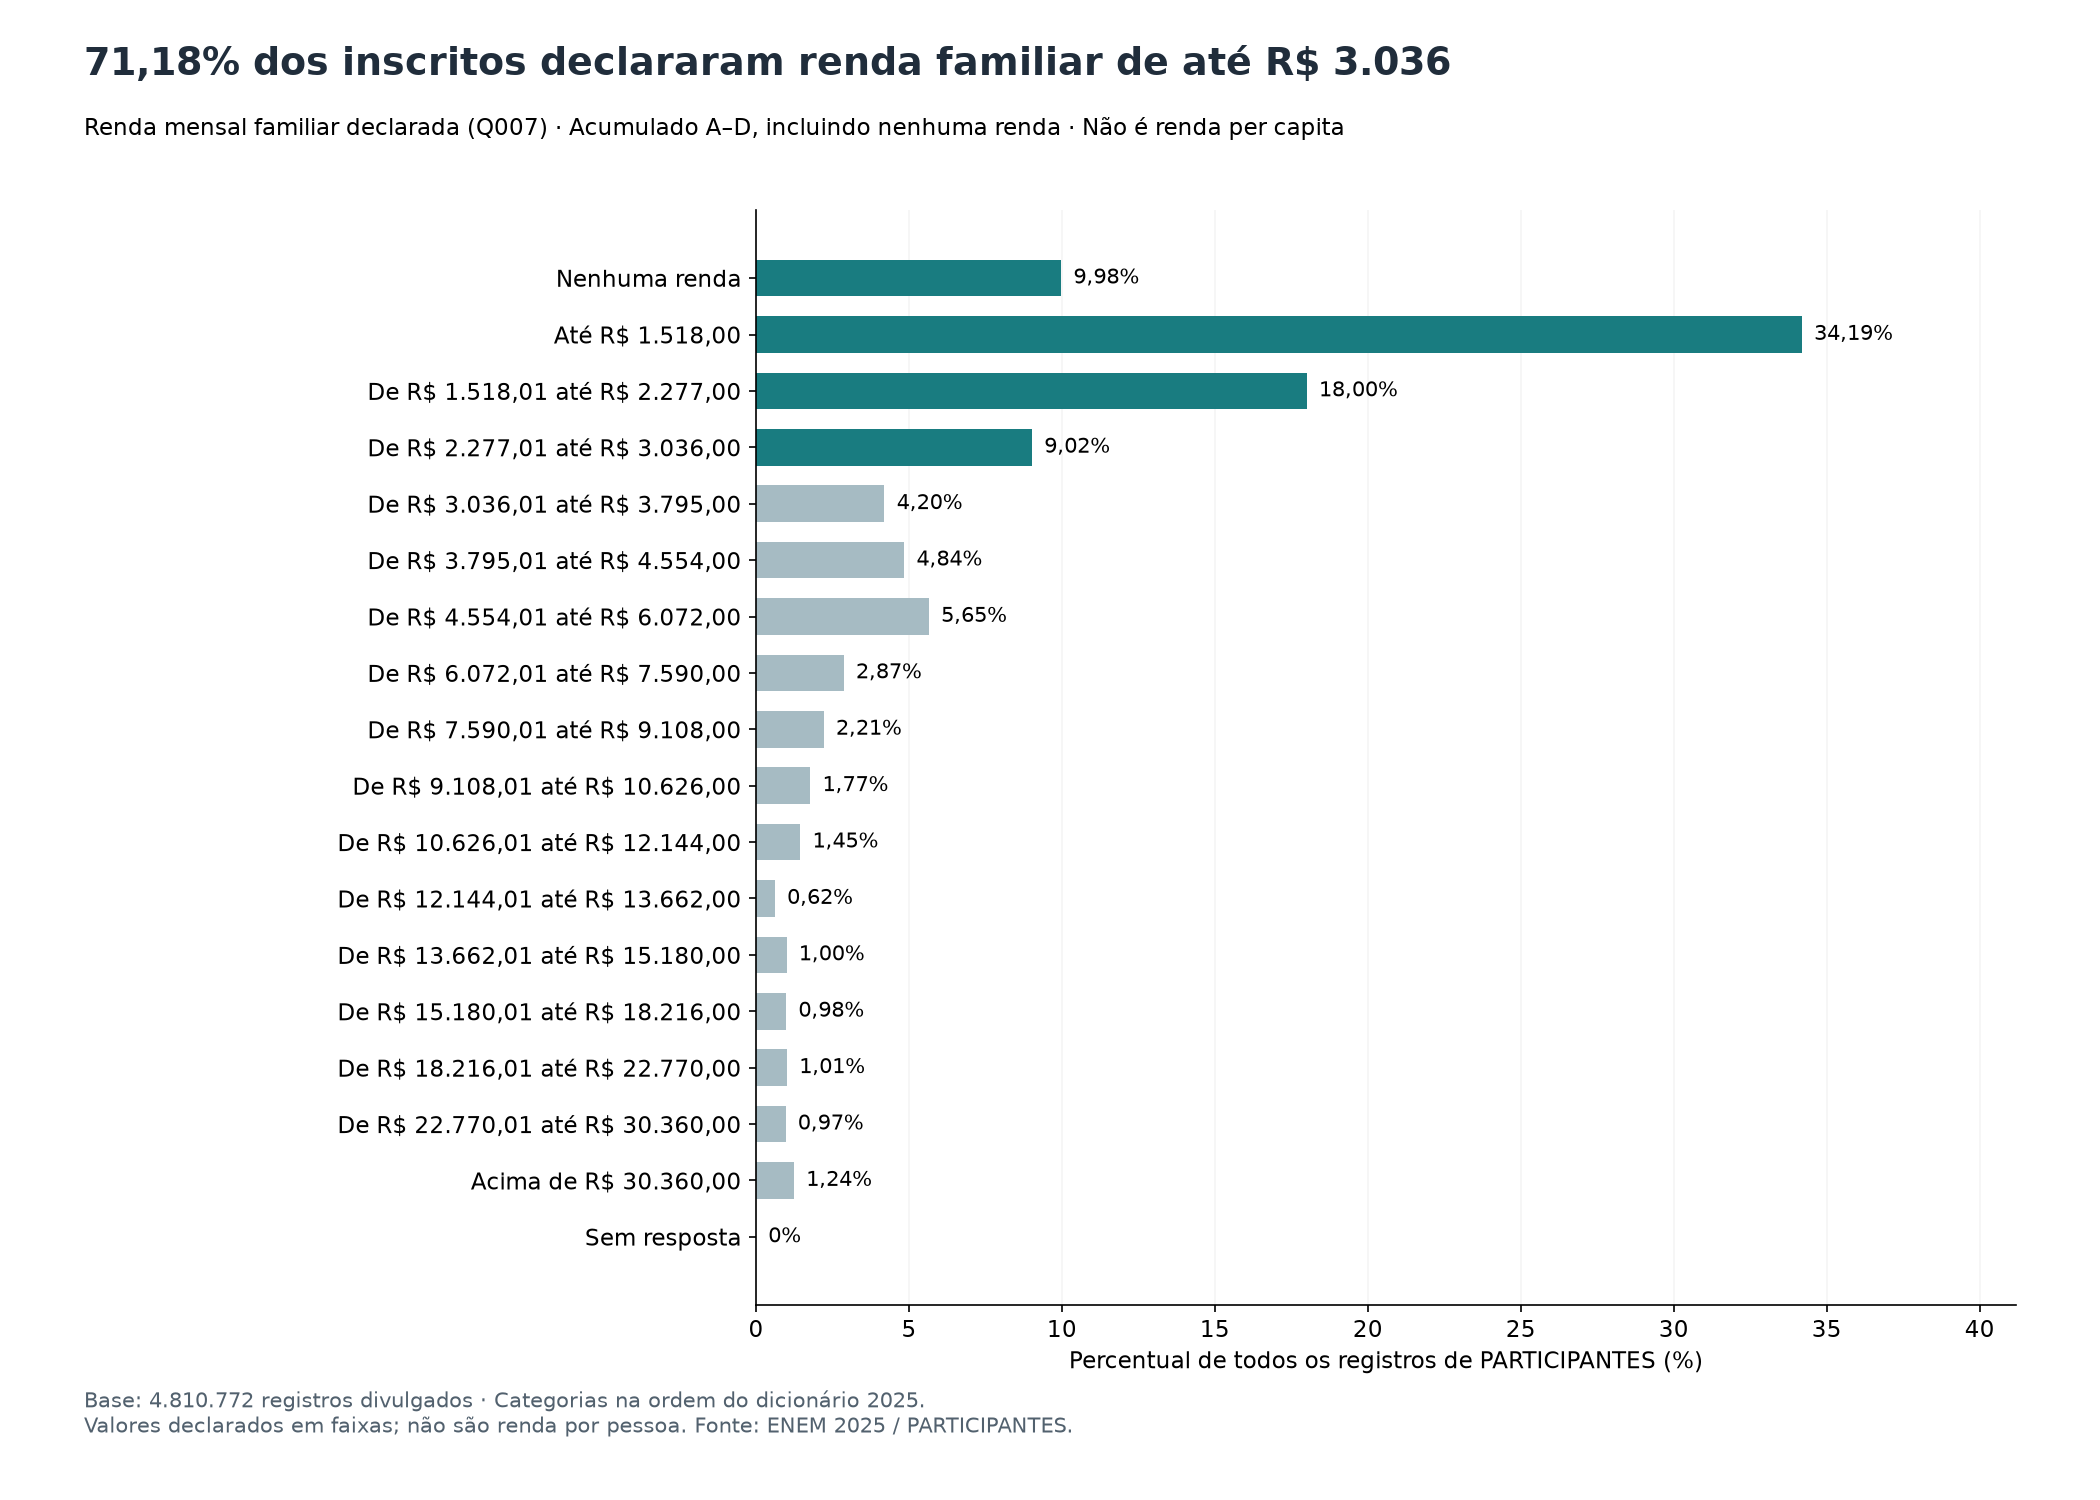

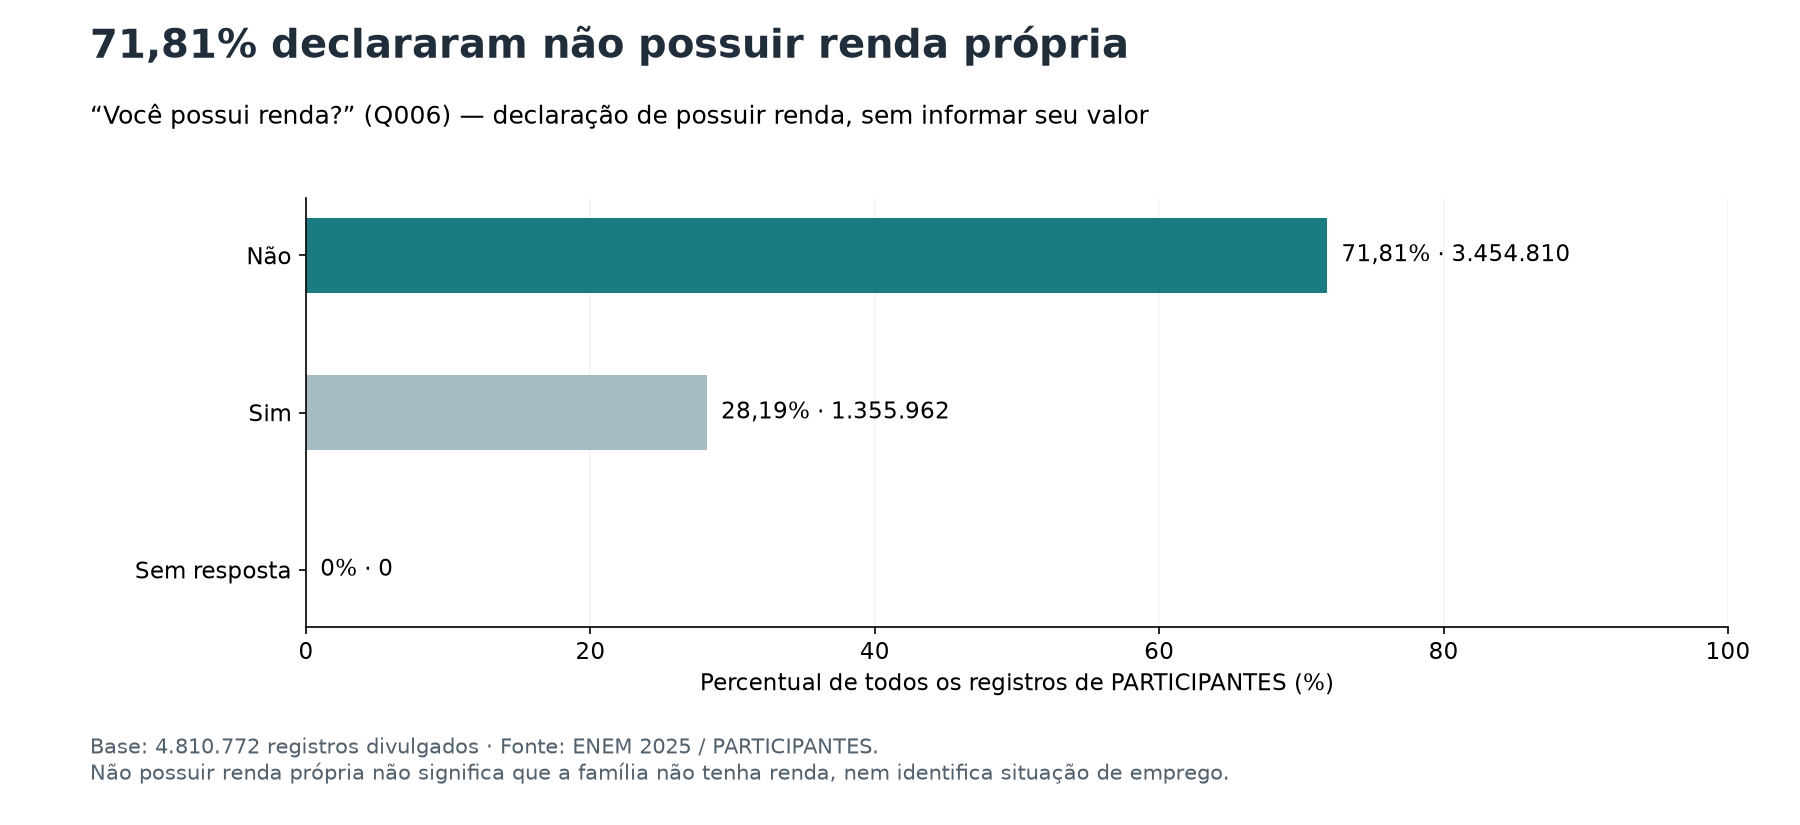

In [1]:
figuras_economicas=gerar_graficos_perfil_economico(economico,raiz/'apresentacao/graficos')
for figura in figuras_economicas:
    display(Image(filename=str(figura)))
